# Sweep: CLS Pooling - Negation Detection

Train probes to detect **negation** (NOT sentiment!) across all layers using CLS pooling.

**Task**: Binary classification
- Label 0: No negation (e.g., "good", "the movie is great")
- Label 1: Has negation (e.g., "not good", "the movie is not great")

**Goal**: Find which layer is best at detecting negation. Expected: Layer 3 (based on cosine similarity findings).

Run this notebook in **Colab 1** while running `07_sweep_mean_negation_detection.ipynb` and `07_sweep_token_negation_detection.ipynb` in separate Colab runtimes.

All results are saved to Google Drive so they can be merged later.


## 1. Setup


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Clone or pull the repository
!git clone https://github.com/TheMattWang/Negation-Origin-Tracing.git 2>/dev/null || (cd Negation-Origin-Tracing && git pull)
%cd Negation-Origin-Tracing


/content/Negation-Origin-Tracing


In [3]:
# Install dependencies
%pip install -q torch lightning transformers datasets pandas pyarrow matplotlib seaborn scikit-learn tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 48.9 MB/s eta 0:00:00


In [4]:
# Set shared output location on Google Drive
import os
os.environ['DRIVE_OUTPUT'] = '/content/drive/MyDrive/NOT_results'

# Create the directory
!mkdir -p /content/drive/MyDrive/NOT_results

print(f"Results will be saved to: {os.environ['DRIVE_OUTPUT']}")


Results will be saved to: /content/drive/MyDrive/NOT_results


In [5]:
# Check GPU
import torch
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


GPU available: True
GPU: Tesla T4


## 2. Prepare Negation Detection Dataset

Download JinaAI negation dataset and convert to detection format:
- Anchor/Entailment sentences → Label 0 (no negation)
- Negative sentences → Label 1 (has negation)


In [6]:
# Check if negation detection dataset already exists
import os

train_path = 'data/raw/train/negation_detection.parquet'
val_path = 'data/raw/validation/negation_detection.parquet'
test_path = 'data/raw/test/negation_detection.parquet'

if os.path.exists(train_path) and os.path.exists(val_path) and os.path.exists(test_path):
    print("Negation detection dataset already exists!")

    # Show stats
    import pandas as pd
    for name, path in [('Train', train_path), ('Validation', val_path), ('Test', test_path)]:
        df = pd.read_parquet(path)
        print(f"  {name}: {len(df)} samples, labels: {sorted(df['label'].unique())}")
else:
    print("Preparing negation detection dataset...")
    !python src/data/prepare_negation_detection.py


Preparing negation detection dataset...
Preparing Negation Detection Dataset
README.md: 3.75kB [00:00, 6.53MB/s]
negation-dataset-v2.py: 4.54kB [00:00, 16.1MB/s]
Error downloading dataset: Dataset scripts are no longer supported, but found negation-dataset-v2.py
Trying fallback: jinaai/negation-dataset...
README.md: 3.99kB [00:00, 15.3MB/s]
negation_training.tsv: 1.39MB [00:00, 161MB/s]
negation_evaluation.tsv: 73.7kB [00:00, 120MB/s]
Generating train split: 100% 10000/10000 [00:00<00:00, 219213.73 examples/s]
Generating test split: 100% 500/500 [00:00<00:00, 92426.27 examples/s]
  Cached train: 10000 examples -> /content/Negation-Origin-Tracing/data/raw/negation/train.parquet
  Cached test: 500 examples -> /content/Negation-Origin-Tracing/data/raw/negation/test.parquet

Converting triplets to negation detection format...

  Processing train split (10000 triplets)...
    -> 27268 detection examples

  Processing test split (500 triplets)...
    -> 1458 detection examples

  Creating va

In [7]:
# Verify the dataset
import pandas as pd

print("Dataset samples:")
print("=" * 60)

train_df = pd.read_parquet('data/raw/train/negation_detection.parquet')

# Show examples of each class
print("\nLabel 0 (No negation):")
for text in train_df[train_df['label'] == 0]['sentence'].head(3).tolist():
    print(f"  - {text[:80]}..." if len(text) > 80 else f"  - {text}")

print("\nLabel 1 (Has negation):")
for text in train_df[train_df['label'] == 1]['sentence'].head(3).tolist():
    print(f"  - {text[:80]}..." if len(text) > 80 else f"  - {text}")

print(f"\nLabel distribution:")
print(train_df['label'].value_counts())


Dataset samples:

Label 0 (No negation):
  - The woman is playing a sport
  - a man walks and reads the paper
  - A crowd has a flag

Label 1 (Has negation):
  - There are no people outdoors.
  - The postal workers are not smiling.
  - a man is not in the grass

Label distribution:
label
0    16014
1     8528
Name: count, dtype: int64


## 3. Run CLS Pooling Sweep - Negation Detection

This trains probes on all 6 layers using CLS pooling to detect negation.


In [8]:
# Run the CLS negation detection sweep
!chmod +x run_sweep_cls_negation_detection.sh
!./run_sweep_cls_negation_detection.sh


Saving to Google Drive: /content/drive/MyDrive/NOT_results/sweep_cls_negation_detection
Layer Sweep: CLS Pooling - NEGATION DETECTION
Task: Binary classification (0=no negation, 1=has negation)
Layers: 0-5
Output: /content/drive/MyDrive/NOT_results/sweep_cls_negation_detection


[Layer 0] CLS pooling - Negation Detection...
2025-12-03 16:58:49.261069: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764781129.281512     932 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764781129.287832     932 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764781129.304776     932 computation_placer.cc:177] computation placer already registered. Please 

## 4. Check Results


In [9]:
import json
import os

results_file = os.path.join(os.environ['DRIVE_OUTPUT'], 'sweep_cls_negation_detection', 'results_cls_negation_detection.json')

if os.path.exists(results_file):
    with open(results_file, 'r') as f:
        results = json.load(f)

    print(f"CLS Negation Detection Sweep Results ({len(results)} experiments)")
    print("=" * 60)
    print("\nTask: Negation Detection (0=no negation, 1=has negation)")
    print("\nResults by layer (sorted by AUROC):")

    for r in sorted(results, key=lambda x: x.get('test_auroc', 0), reverse=True):
        print(f"  Layer {r['layer']}: AUROC={r.get('test_auroc', 0):.4f}, Acc={r.get('test_acc', 0):.4f}")

    best = max(results, key=lambda x: x.get('test_auroc', 0))
    print(f"\n🏆 Best: Layer {best['layer']} with AUROC {best.get('test_auroc', 0):.4f}")

    # Check if Layer 3 is best (expected based on cosine similarity)
    if best['layer'] == 3:
        print("\n✅ Layer 3 is best for negation detection!")
        print("   This connects with the cosine similarity findings.")
    else:
        print(f"\n⚠️ Layer {best['layer']} is best (not Layer 3)")
        print("   This may suggest a different pattern than cosine similarity.")
else:
    print(f"Results not found at {results_file}")


CLS Negation Detection Sweep Results (6 experiments)

Task: Negation Detection (0=no negation, 1=has negation)

Results by layer (sorted by AUROC):
  Layer 5: AUROC=0.9472, Acc=0.8957
  Layer 4: AUROC=0.9401, Acc=0.9026
  Layer 3: AUROC=0.9336, Acc=0.8999
  Layer 2: AUROC=0.9255, Acc=0.8841
  Layer 1: AUROC=0.9010, Acc=0.8491
  Layer 0: AUROC=0.8827, Acc=0.8484

🏆 Best: Layer 5 with AUROC 0.9472

⚠️ Layer 5 is best (not Layer 3)
   This may suggest a different pattern than cosine similarity.


Figure saved to: /content/drive/MyDrive/NOT_results/sweep_cls_negation_detection/cls_negation_detection_results.png


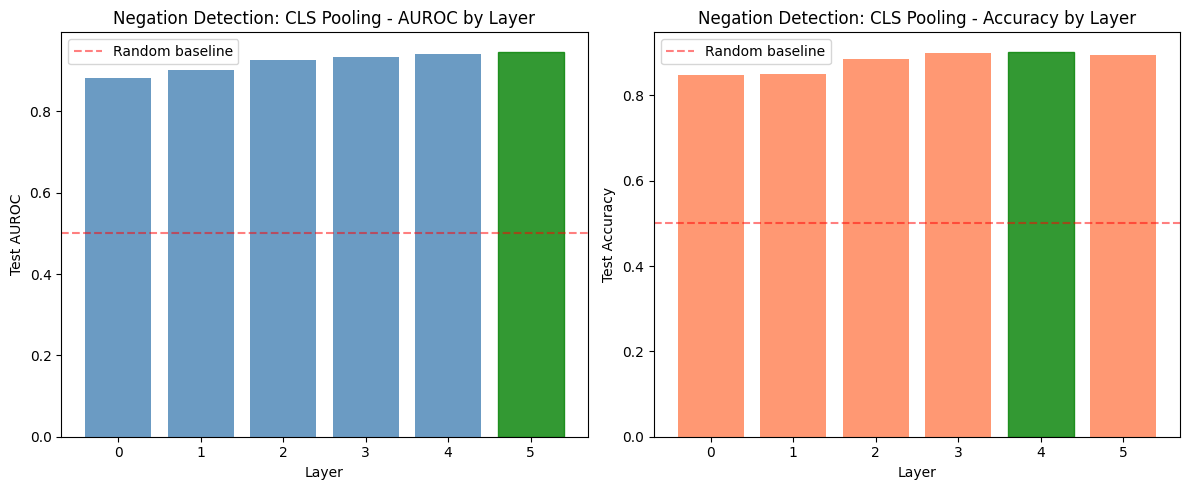

In [10]:
# Visualize results
import matplotlib.pyplot as plt
import json
import os

results_file = os.path.join(os.environ['DRIVE_OUTPUT'], 'sweep_cls_negation_detection', 'results_cls_negation_detection.json')

if os.path.exists(results_file):
    with open(results_file, 'r') as f:
        results = json.load(f)

    # Sort by layer
    results = sorted(results, key=lambda x: x['layer'])

    layers = [r['layer'] for r in results]
    aurocs = [r.get('test_auroc', 0) for r in results]
    accs = [r.get('test_acc', 0) for r in results]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # AUROC plot
    bars1 = ax1.bar(layers, aurocs, color='steelblue', alpha=0.8)
    ax1.set_xlabel('Layer')
    ax1.set_ylabel('Test AUROC')
    ax1.set_title('Negation Detection: CLS Pooling - AUROC by Layer')
    ax1.set_xticks(layers)
    ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
    ax1.legend()

    # Highlight best layer
    best_idx = aurocs.index(max(aurocs))
    bars1[best_idx].set_color('green')

    # Accuracy plot
    bars2 = ax2.bar(layers, accs, color='coral', alpha=0.8)
    ax2.set_xlabel('Layer')
    ax2.set_ylabel('Test Accuracy')
    ax2.set_title('Negation Detection: CLS Pooling - Accuracy by Layer')
    ax2.set_xticks(layers)
    ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
    ax2.legend()

    # Highlight best layer
    best_idx = accs.index(max(accs))
    bars2[best_idx].set_color('green')

    plt.tight_layout()

    # Save figure
    fig_path = os.path.join(os.environ['DRIVE_OUTPUT'], 'sweep_cls_negation_detection', 'cls_negation_detection_results.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"Figure saved to: {fig_path}")

    plt.show()
else:
    print("No results to visualize")
